In [4]:
%cd Multi-Domain-Pruning

/home/blanka/Multi-Domain-Pruning


/data/blanka/virtualenvs/yolov10/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
from src.model.yolo_handler import ModelHandler
from utils.config_parser import ConfigParser


In [6]:
conf = ConfigParser.read("config/pruning/pruning_sampling.ini")


model_handler = ModelHandler(conf.model)
model = model_handler.model
print(model)
model_handler.flatten_conv_layers()
model_handler.determine_prunable_layers()
prunable_layers = model_handler.prunable_layers
#for layer in flattened_layers:
#    print(layer)
#model_handler.evaluate()


/data/blanka/virtualenvs/yolov10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



                   from  n    params  module                                       arguments                     
  0                  -1  1      2320  ultralytics.nn.modules.conv.Conv             [3, 80, 3, 2]                 
  1                  -1  1    115520  ultralytics.nn.modules.conv.Conv             [80, 160, 3, 2]               
  2                  -1  3    436800  ultralytics.nn.modules.block.C2f             [160, 160, 3, True]           
  3                  -1  1    461440  ultralytics.nn.modules.conv.Conv             [160, 320, 3, 2]              
  4                  -1  6   3281920  ultralytics.nn.modules.block.C2f             [320, 320, 6, True]           
  5                  -1  1    213120  ultralytics.nn.modules.block.SCDown          [320, 640, 3, 2]              
  6                  -1  6   4604160  ultralytics.nn.modules.block.C2fCIB          [640, 640, 6, True]           
  7                  -1  1    417920  ultralytics.nn.modules.block.SCDown          [640

In [ ]:
conf.channel_selection.skipunder

0

# Alpha generator 

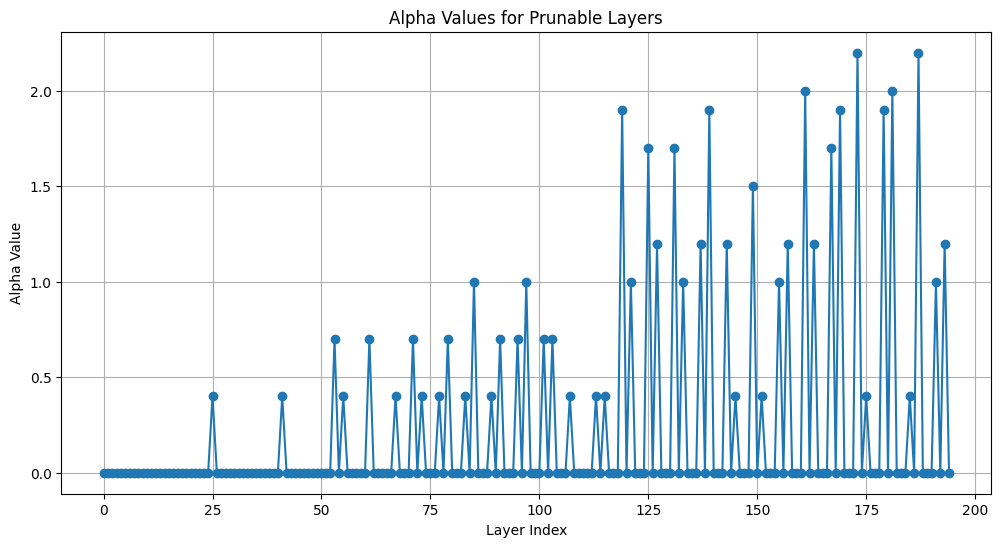

In [9]:
from src.action_handler import ActionHandler

action_handler = ActionHandler(conf, len(prunable_layers))
action_handler.define_alpha_list()
action_handler.define_alpha_pdfs()


import matplotlib.pyplot as plt

# Initialize lists to collect data
indices = []
alphas = []

# Collect data
for i, layer in enumerate(prunable_layers):
    alpha, _ = action_handler.choose_alpha(i)
    indices.append(i)
    alphas.append(alpha)

plt.figure(figsize=(12, 6))  # Set a wider figure size
plt.plot(indices, alphas, marker='o')
plt.xlabel('Layer Index')
plt.ylabel('Alpha Value')
plt.title('Alpha Values for Prunable Layers')
plt.grid(True)  # Add grid lines
plt.show()


